In [1]:
from langgraph.graph import StateGraph

In [2]:
from langchain_cohere.embeddings import CohereEmbeddings
cohere_embeddings = CohereEmbeddings(model="embed-english-light-v3.0")

In [3]:
text = "This is a test document."
query_result = cohere_embeddings.embed_query(text)
print(query_result)
print(len(query_result))

[-0.09338379, 0.0871582, -0.03326416, 0.01953125, 0.07702637, 0.034729004, -0.058380127, -0.031021118, -0.030517578, -0.055999756, 0.050842285, -0.006752014, 0.038391113, -0.0014362335, -0.041137695, -0.008880615, 0.026000977, -0.023010254, 0.05456543, -0.03366089, 0.055633545, 0.028579712, -0.068603516, 0.03970337, -0.06677246, 0.06732178, -0.013053894, -0.0060920715, 0.038116455, 0.057800293, 0.048736572, 0.026855469, 0.009849548, 0.08312988, 0.073791504, 0.01663208, -0.0871582, 0.01802063, -0.0020828247, -0.0031356812, 0.039978027, -0.03164673, 0.009796143, 0.011375427, 0.0068855286, 0.092285156, 0.05218506, -0.060943604, 0.038269043, -0.018218994, -0.04510498, -0.0847168, 0.008300781, -0.060058594, 0.0012111664, 0.05102539, 0.05218506, -0.047210693, -0.051239014, -0.044158936, -0.058166504, 0.07849121, -0.019165039, 0.06451416, 0.024887085, 0.011405945, -0.03768921, -0.018814087, -0.06829834, -0.052825928, -0.019104004, -0.021194458, 0.043518066, 0.07525635, 0.082336426, 0.00376510

In [4]:
from langchain_groq import ChatGroq

def LLMinput(state):
    llm = ChatGroq(model="llama-3.1-8b-instant")
    last_message = state["messages"][-1].content
    response = llm.invoke(last_message)
    return {"messages": [response]}

In [5]:
def count_tokens(state):
    last_message = state["messages"][-1].content
    splitted_tokens = last_message.split()
    token_length = f"Total number of tokens in the given sentence is {len(splitted_tokens)}"
    from langchain_core.messages import AIMessage
    return {"messages": [AIMessage(content=token_length)]}

In [6]:
from typing import Annotated, Sequence
from typing_extensions import TypedDict

from langchain_core.messages import BaseMessage

from langgraph.graph.message import add_messages


class AgentState(TypedDict):
    # The add_messages function defines how an update should be processed
    # Default is to replace. add_messages says "append"
    messages: Annotated[Sequence[BaseMessage], add_messages]


In [7]:
workflow = StateGraph(AgentState)

In [8]:
# from langgraph.graph import END, StateGraph, START
# from langgraph.prebuilt import ToolNode
# from langgraph.prebuilt import tools_condition

# workflow.add_node("My LLM",LLMinput)
# workflow.add_node("Token Count", count_tokens)

# workflow.add_edge(START,"My LLM")
# workflow.add_edge("My LLM","Token Count")
# workflow.add_edge("Token Count",END)

from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Only add nodes if they don't exist
if "My LLM" not in workflow.nodes:
    workflow.add_node("My LLM", LLMinput)
if "Token Count" not in workflow.nodes:
    workflow.add_node("Token Count", count_tokens)

# Add edges (these can be re-added without issue)
workflow.add_edge(START, "My LLM")
workflow.add_edge("My LLM", "Token Count")
workflow.add_edge("Token Count", END)

In [9]:
app = workflow.compile()

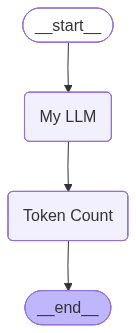

In [10]:
from IPython.display import Image

# Display the graph as a PNG image
Image(app.get_graph().draw_mermaid_png())

In [11]:
from langchain_core.messages import HumanMessage

# Invoke the graph with a proper state dict
result = app.invoke({"messages": [HumanMessage(content="what is agentic ai ?, explain me in short answer")]})

# Print the final response
print(result["messages"][-1].content)

Total number of tokens in the given sentence is 95


In [12]:
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages

# ✅ Define State
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

# ✅ Define a node (your function)
def llm_node(state: AgentState):
    print("STATE INSIDE NODE:", state)

    last_message = state["messages"][-1].content

    # fake LLM response (no API needed)
    response = AIMessage(content=f"Echo: {last_message}")

    return {"messages": [response]}

# ✅ Build graph
graph = StateGraph(AgentState)

graph.add_node("llm_node", llm_node)

graph.set_entry_point("llm_node")
graph.add_edge("llm_node", END)

# ✅ Compile graph
app = graph.compile()

# ✅ Invoke graph (THIS is where state starts)
result = app.invoke({
    "messages": [HumanMessage(content="Hello")]
})

print("\nFINAL RESULT:")
for msg in result["messages"]:
    print(msg)

STATE INSIDE NODE: {'messages': [HumanMessage(content='Hello', additional_kwargs={}, response_metadata={}, id='cf7a1d0e-8476-49ce-8031-833ae4c92efd')]}

FINAL RESULT:
content='Hello' additional_kwargs={} response_metadata={} id='cf7a1d0e-8476-49ce-8031-833ae4c92efd'
content='Echo: Hello' additional_kwargs={} response_metadata={} id='e177362c-b189-4ab6-a2ce-3fc54d507104' tool_calls=[] invalid_tool_calls=[]
